# Actigraphy tutorial: visit pyramid and contrastive relapse risk

Dr. Frank Rudzicz Lab -- Centre for Analytics (CfA)

This notebook walks through the **actigraphy** processing used for depression-relapse early warning on CAN-BIND / CBN-WELL.

It runs on the synthetic tables in `test_data/` (10 invented people, 80 visits). Those files mimic column names and the 7 / 14 / 28-day visit construction. They are **not** actual data.

**Goal:** from daily wearable features available *before* a MADRS visit, build a 72-dimensional visit vector, embed it, and score how far it sits from the stable-visit neighbourhood using the same **k = 20** KNN rule as the analysis.

## 1. What the real pipeline does

1. Preprocess wear time and daily features; keep participants with enough valid days and MADRS visits.
2. Label visits relative to first relapse (**zones**).
3. Keep six daily features that passed association, temporal change, redundancy, and interpretability checks.
4. Build a **temporal pyramid** (7 / 14 / 28 days before the visit).
5. Train a visit encoder with **contrastive** loss (stable together, prodrome apart).
6. Score **distance from the stable set** (KNN, k = 20).

Leakage rule used throughout: for a visit on day \(t\), use only actigraphy with date **strictly before** \(t\). Relapser days after first relapse are dropped.

The demo tables are still synthetic, but they are large enough for a real 20-neighbour stable manifold (tens of stable visits, plus early / late / imminent prodrome). The 40% availability gate is the same filter as the analysis.

In the analysis, a patient-level rule required elevated risk to be sustained; Youden thresholds were chosen on **train patients only**. This notebook plots risk trajectories. It does not report a confusion matrix or a “flagged patient” count.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "test_data").exists():
    ROOT = Path("Rudzicz-Lab")
DATA = ROOT / "test_data"

daily = pd.read_csv(DATA / "sample_actigraphy.csv", parse_dates=["date"])
visits = pd.read_csv(DATA / "sample_visits.csv", parse_dates=["visit_date"])
visits["relapse_date"] = pd.to_datetime(visits["relapse_date"], errors="coerce")

print(daily.shape, "daily rows;", visits.shape, "visits")
print("patients:", sorted(daily["patient_id"].unique()))
daily.head()

(2109, 8) daily rows; (80, 5) visits
patients: ['SYN_001', 'SYN_002', 'SYN_003', 'SYN_004', 'SYN_005', 'SYN_006', 'SYN_007', 'SYN_008', 'SYN_009', 'SYN_010']


,patient_id,date,intradaily_variability,total_sleep_time,sleep_efficiency,mean_activity,sleep_onset_latency,num_awakenings
0,SYN_001,2018-01-01,0.837925,426.162070,0.882188,177.725267,11.041767,1.836086
1,SYN_001,2018-01-02,0.790468,421.313351,0.909797,190.710192,16.527071,1.241719
2,SYN_001,2018-01-03,0.861718,411.180996,0.890848,154.580436,9.552311,0.694959
3,SYN_001,2018-01-04,0.743953,433.797701,0.903135,182.009105,3.416201,1.476784
4,SYN_001,2018-01-05,0.826799,408.578099,0.890445,169.343695,11.955814,2.436539


## 2. Relapse label and visit zones

Study labels in the executed code: `CNSR == 0` is a relapser; first date is `ADT`, or the first MADRS ≥ 22 if `ADT` is missing.

For a relapser, `days_to_relapse = (first_relapse_date − visit_date)`.

| Zone | Window |
|------|--------|
| imminent | 0–14 days |
| late prodrome | 14–28 days |
| early prodrome | 28–84 days |
| stable | > 84 days |

84 days (12 weeks) is used so that typical bimonthly visits still produce pre-relapse samples. Non-relapsers: every visit is `stable`. Post-relapse visits are discarded.

In [2]:
PRODROME_DAYS = 84


def get_zone(days_to_relapse):
    if pd.isna(days_to_relapse):
        return "stable"
    if days_to_relapse < 0:
        return "post_relapse"
    if days_to_relapse < 14:
        return "imminent"
    if days_to_relapse < 28:
        return "late_prodrome"
    if days_to_relapse < PRODROME_DAYS:
        return "early_prodrome"
    return "stable"


labelled = visits.copy()
labelled["days_to_relapse"] = (labelled["relapse_date"] - labelled["visit_date"]).dt.days
labelled.loc[labelled["cnsr"] == 1, "days_to_relapse"] = np.nan
labelled["zone"] = labelled["days_to_relapse"].apply(get_zone)
labelled.loc[labelled["cnsr"] == 1, "zone"] = "stable"
labelled[["patient_id", "visit_date", "madrs_score", "cnsr", "days_to_relapse", "zone"]]

,patient_id,visit_date,madrs_score,cnsr,days_to_relapse,zone
0,SYN_001,2018-02-15,6,0,167.0,stable
1,SYN_001,2018-03-15,5,0,139.0,stable
2,SYN_001,2018-04-12,7,0,111.0,stable
3,SYN_001,2018-05-10,8,0,83.0,early_prodrome
4,SYN_001,2018-06-07,11,0,55.0,early_prodrome
...,...,...,...,...,...,...
75,SYN_010,2018-05-14,7,1,NaN,stable
76,SYN_010,2018-06-11,5,1,NaN,stable
77,SYN_010,2018-07-09,6,1,NaN,stable
78,SYN_010,2018-08-06,7,1,NaN,stable


## 3. Six daily features

Features were kept only if they (1) associated with outcome, (2) changed toward relapse, (3) were not redundant with a simpler feature, and (4) were clinically interpretable.

The six that remain:

- `intradaily_variability`
- `total_sleep_time`
- `sleep_efficiency`
- `mean_activity`
- `sleep_onset_latency`
- `num_awakenings`

## 4. Temporal pyramid (7 / 14 / 28 days)

For each visit and each of the six features, over each window ending the day before the visit:

- **mean**, **std**, **velocity** `(last − first) / day_span`
- **availability** = (days with data) / window length

That is \(6 \times 3 \times 3 = 54\) summaries plus \(6 \times 3 = 18\) availability values = **72** inputs. A visit is dropped if **any** window has availability below 40%.

Availability stays in \([0, 1]\). In the full analysis, other columns are per-patient robust-scaled (median/IQR, IQR floored, clip \(\pm 10\)). The demo skips scaling so the arithmetic stays visible.

In [3]:
DAILY_FEATURES = [
    "intradaily_variability",
    "total_sleep_time",
    "sleep_efficiency",
    "mean_activity",
    "sleep_onset_latency",
    "num_awakenings",
]
MIN_WINDOW_AVAILABILITY = 0.40


class SmartTemporalPyramid:
    def __init__(self, feature_cols, scales=(7, 14, 28), min_window_availability=0.40):
        self.feature_cols = list(feature_cols)
        self.scales = scales
        self.min_window_availability = min_window_availability

    def build_pyramid(self, patient_daily, end_date):
        df = patient_daily.copy()
        df["date"] = pd.to_datetime(df["date"])
        end = pd.Timestamp(end_date)
        past = df[df["date"] < end].sort_values("date")
        if past.empty:
            return None
        out, avails = {}, []
        for w in self.scales:
            start = end - pd.Timedelta(days=w)
            window = past[(past["date"] > start) & (past["date"] < end)]
            avail = 0.0 if window.empty else len(window) / max(w, 1)
            avails.append(avail)
            for f in self.feature_cols:
                vals = window[f].dropna() if not window.empty else pd.Series(dtype=float)
                if len(vals) == 0:
                    out[f"{f}_mean_{w}d"] = out[f"{f}_std_{w}d"] = out[f"{f}_velocity_{w}d"] = 0.0
                else:
                    out[f"{f}_mean_{w}d"] = float(vals.mean())
                    out[f"{f}_std_{w}d"] = float(vals.std()) if len(vals) > 1 else 0.0
                    dates_f = window.loc[vals.index, "date"]
                    if len(dates_f) >= 2:
                        span = (dates_f.max() - dates_f.min()).days or 1
                        out[f"{f}_velocity_{w}d"] = float(vals.iloc[-1] - vals.iloc[0]) / span
                    else:
                        out[f"{f}_velocity_{w}d"] = 0.0
                out[f"{f}_availability_{w}d"] = avail
        if min(avails) < self.min_window_availability:
            return None
        return out


pyramid = SmartTemporalPyramid(DAILY_FEATURES, min_window_availability=MIN_WINDOW_AVAILABILITY)
rows = []
skipped = 0
for rec in labelled.itertuples(index=False):
    if rec.zone == "post_relapse":
        skipped += 1
        continue
    pat = daily[daily["patient_id"] == rec.patient_id]
    feat = pyramid.build_pyramid(pat, rec.visit_date)
    if feat is None:
        skipped += 1
        continue
    feat.update(
        patient_id=rec.patient_id,
        visit_date=rec.visit_date,
        madrs_score=rec.madrs_score,
        cnsr=rec.cnsr,
        zone=rec.zone,
        days_to_relapse=rec.days_to_relapse,
    )
    rows.append(feat)

visit_features = pd.DataFrame(rows)
feature_cols = [c for c in visit_features.columns if any(f in c for f in DAILY_FEATURES)]
avail_cols = [c for c in feature_cols if "availability" in c]
scale_cols = [c for c in feature_cols if c not in avail_cols]

# Per-patient robust scale (median/IQR). Availability stays in [0, 1].
for pid, g in visit_features.groupby("patient_id"):
    for c in scale_cols:
        med = g[c].median()
        iqr = float(g[c].quantile(0.75) - g[c].quantile(0.25))
        iqr = max(iqr, 1e-6)
        visit_features.loc[g.index, c] = ((g[c] - med) / iqr).clip(-10, 10)

print(f"kept {len(visit_features)} visits; skipped {skipped} (availability or post-relapse)")
print("n features:", len(feature_cols))
print("zones:\n", visit_features["zone"].value_counts().to_string())
n_stable_anchors = int(
    ((visit_features["zone"] == "stable") & (visit_features["madrs_score"] <= 10)).sum()
)
print("stable anchors (zone=stable and MADRS ≤ 10):", n_stable_anchors)
visit_features[["patient_id", "visit_date", "madrs_score", "zone"] + feature_cols[:3]]

kept 80 visits; skipped 0 (availability or post-relapse)
n features: 72
zones:
 zone
stable            62
early_prodrome    10
late_prodrome      4
imminent           4
stable anchors (zone=stable and MADRS ≤ 10): 62


,patient_id,visit_date,madrs_score,zone,intradaily_variability_mean_7d,intradaily_variability_std_7d,intradaily_variability_velocity_7d
0,SYN_001,2018-02-15,6,stable,-1.006234,1.467433,3.385642
1,SYN_001,2018-03-15,5,stable,-0.692411,-1.181165,-0.843102
2,SYN_001,2018-04-12,7,stable,-0.262365,-0.204752,-1.350561
3,SYN_001,2018-05-10,8,early_prodrome,-0.043197,0.611454,0.118541
4,SYN_001,2018-06-07,11,early_prodrome,0.043197,0.588586,2.034115
...,...,...,...,...,...,...,...
75,SYN_010,2018-05-14,7,stable,-0.782965,-0.608257,-0.852877
76,SYN_010,2018-06-11,5,stable,0.392461,0.052554,0.634494
77,SYN_010,2018-07-09,6,stable,-0.501641,4.135491,0.519893
78,SYN_010,2018-08-06,7,stable,0.534729,-3.360706,-0.342439


## 5. Contrastive encoder

**Anchors:** `zone == stable` and MADRS ≤ 10.
**Positive:** another stable visit from the same person (or the anchor plus small noise if only one exists).
**Negative:** a **prodrome** visit — same person (hard, loss weight 2.0) or a different person. Other people's *stable* visits are never negatives (that had inflated false positives).

Encoder: MLP `72 → 256 → 64`, LayerNorm, ReLU, dropout 0.2, **L2-normalized** output. Loss is InfoNCE-style with temperature 0.07.

The cell below trains a short CPU run on the demo visits so the API is visible. The real run used the full cohort and more epochs.

A low toy loss here is **expected**: the synthetic tables are deliberately structured (relapsers drift toward relapse; non-relapsers stay near baseline). That number is **not** clinical performance and is not a claim that the model “performs well.”

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class VisitEncoder(nn.Module):
    def __init__(self, input_dim=72, hidden_dim=256, embedding_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, embedding_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), p=2, dim=1)


def supcon_loss(anchor, pos, neg, is_hard, temp=0.07, hard_weight=2.0):
    pos_sim = (anchor * pos).sum(1) / temp
    neg_sim = (anchor * neg).sum(1) / temp
    logits = torch.stack([pos_sim, neg_sim], 1)
    labels = torch.zeros(anchor.size(0), dtype=torch.long, device=anchor.device)
    loss = F.cross_entropy(logits, labels, reduction="none")
    weights = torch.where(is_hard, torch.full_like(loss, hard_weight), torch.ones_like(loss))
    return (loss * weights).mean()


def row_tensor(row, cols):
    vals = pd.to_numeric(row[cols], errors="coerce").fillna(0).astype(np.float32).values
    return torch.from_numpy(np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0))


stable = visit_features[(visit_features["zone"] == "stable") & (visit_features["madrs_score"] <= 10)]
prodrome = visit_features[visit_features["zone"].isin(["imminent", "late_prodrome", "early_prodrome"])]
print(f"stable anchors: {len(stable)}; prodrome: {len(prodrome)}")

encoder = VisitEncoder(input_dim=len(feature_cols))
opt = torch.optim.Adam(encoder.parameters(), lr=1e-3)
rng = np.random.default_rng(0)

if len(stable) == 0 or len(prodrome) == 0:
    print("Need at least one stable and one prodrome visit in the demo table to train.")
else:
    encoder.train()
    for step in range(200):
        a_row = stable.sample(1, random_state=int(rng.integers(1e9))).iloc[0]
        same = stable[stable["patient_id"] == a_row["patient_id"]]
        if len(same) >= 2:
            p_row = same.drop(index=a_row.name).sample(1, random_state=int(rng.integers(1e9))).iloc[0]
            pos = row_tensor(p_row, feature_cols)
        else:
            pos = row_tensor(a_row, feature_cols) + 0.01 * torch.randn(len(feature_cols))
        hard = rng.random() < 0.5
        same_prod = prodrome[prodrome["patient_id"] == a_row["patient_id"]]
        if hard and len(same_prod):
            n_row = same_prod.sample(1, random_state=int(rng.integers(1e9))).iloc[0]
        else:
            n_row = prodrome.sample(1, random_state=int(rng.integers(1e9))).iloc[0]
            hard = n_row["patient_id"] == a_row["patient_id"]
        opt.zero_grad()
        z_a = encoder(row_tensor(a_row, feature_cols).unsqueeze(0))
        z_p = encoder(pos.unsqueeze(0))
        z_n = encoder(row_tensor(n_row, feature_cols).unsqueeze(0))
        loss = supcon_loss(z_a, z_p, z_n, torch.tensor([hard]))
        loss.backward()
        opt.step()
    print("toy loss after 200 steps:", float(loss.detach()))
    print(
        "This loss is not clinical performance. The synthetic tables are deliberately structured, so a low value is expected."
    )
    with torch.no_grad():
        z = encoder(row_tensor(visit_features.iloc[0], feature_cols).unsqueeze(0))
    print("embedding shape", tuple(z.shape), "L2", float(z.norm()))

stable anchors: 62; prodrome: 18
toy loss after 200 steps: 0.051058199256658554
This loss is not clinical performance. The synthetic tables are deliberately structured, so a low value is expected.
embedding shape (1, 64) L2 1.0


## 6. Distance from the stable manifold (KNN)

At detection time, fit KNN (**k = 20**) on stable embeddings. Risk is mean distance to that neighbourhood, divided by the typical stable-to-stable distance. The demo tables are sized so there are enough stable visits to use k = 20 without clipping.

The plot below is **one synthetic relapser** (`SYN_001`) so the sequence stable → early prodrome → late prodrome → imminent is visible. The dashed line is an **illustrative** threshold only. In the analysis, Youden thresholds were chosen on train folds; they are not validated clinical decision boundaries. This notebook does not report patient flags or a confusion matrix.

KNN k=20; n_stable=62; baseline=0.2577

Mean demo risk by zone (illustration, not a performance table):
                count   mean  median
zone                                
early_prodrome     10  3.115   3.183
imminent            4  4.216   4.121
late_prodrome       4  4.072   4.088
stable             62  1.000   0.981


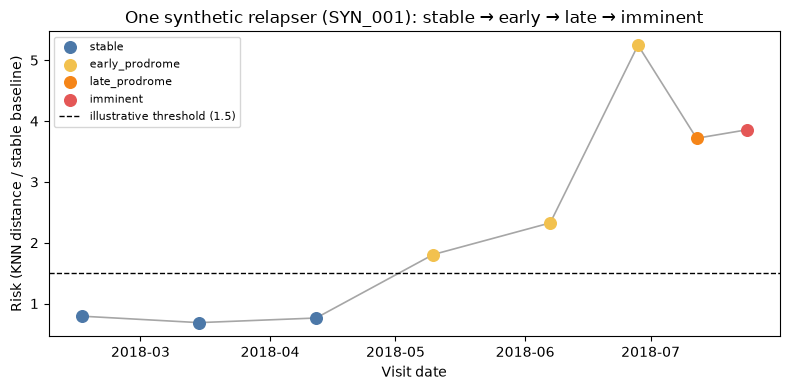

visit_date           zone  madrs_score     risk
2018-02-15         stable            6 0.792605
2018-03-15         stable            5 0.686518
2018-04-12         stable            7 0.762241
2018-05-10 early_prodrome            8 1.805270
2018-06-07 early_prodrome           11 2.326002
2018-06-28 early_prodrome           14 5.247110
2018-07-12  late_prodrome           17 3.717223
2018-07-24       imminent           21 3.855922
Thresholds are illustrative only and are not validated clinical decision boundaries.
Risk is distance from the learned stable manifold and is not constrained to increase monotonically with proximity to relapse.


In [7]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

KNN_K = 20
# Illustrative only — not a validated clinical decision boundary.
# One analysis run used a Youden threshold near 1.9 on train folds.
ILLUSTRATIVE_THRESHOLD = 1.5


class TrajectoryRelapseDetector:
    def __init__(self, encoder, visit_features_df, feature_cols, n_neighbors=20):
        self.encoder = encoder.eval()
        self.df = visit_features_df
        self.feature_cols = feature_cols
        stable_df = self.df[(self.df["zone"] == "stable") & (self.df["madrs_score"] <= 10)]
        if len(stable_df) < n_neighbors:
            raise ValueError(
                f"Need at least {n_neighbors} stable visits for k={n_neighbors}; got {len(stable_df)}."
            )
        embs = []
        with torch.no_grad():
            for _, row in stable_df.iterrows():
                x = row_tensor(row, feature_cols).unsqueeze(0)
                embs.append(self.encoder(x).numpy()[0])
        self.stable_emb = np.array(embs)
        self.knn = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean")
        self.knn.fit(self.stable_emb)
        dists, _ = self.knn.kneighbors(self.stable_emb)
        self.baseline_dist = np.mean(dists)
        self.n_neighbors = n_neighbors

    def embed(self, row):
        with torch.no_grad():
            return self.encoder(row_tensor(row, self.feature_cols).unsqueeze(0)).numpy()

    def risk_score(self, z):
        if z.ndim == 1:
            z = z.reshape(1, -1)
        dists, _ = self.knn.kneighbors(z)
        return float(np.mean(dists) / (self.baseline_dist + 1e-8))


detector = TrajectoryRelapseDetector(encoder, visit_features, feature_cols, n_neighbors=KNN_K)
scored = visit_features.copy()
scored["risk"] = [detector.risk_score(detector.embed(row)) for _, row in scored.iterrows()]
print(f"KNN k={detector.n_neighbors}; n_stable={len(detector.stable_emb)}; baseline={detector.baseline_dist:.4f}")
print("\nMean demo risk by zone (illustration, not a performance table):")
print(scored.groupby("zone")["risk"].agg(["count", "mean", "median"]).round(3).to_string())

example_id = "SYN_001"
ex = scored[scored["patient_id"] == example_id].sort_values("visit_date")
zone_color = {
    "stable": "#4c78a8",
    "early_prodrome": "#f2c14e",
    "late_prodrome": "#f58518",
    "imminent": "#e45756",
}
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ex["visit_date"], ex["risk"], color="0.65", lw=1.2)
seen = set()
for _, row in ex.iterrows():
    label = row["zone"] if row["zone"] not in seen else None
    seen.add(row["zone"])
    ax.scatter(
        row["visit_date"],
        row["risk"],
        color=zone_color[row["zone"]],
        s=70,
        zorder=3,
        label=label,
    )
ax.axhline(
    ILLUSTRATIVE_THRESHOLD,
    color="k",
    ls="--",
    lw=1,
    label=f"illustrative threshold ({ILLUSTRATIVE_THRESHOLD})",
)
ax.set_xlabel("Visit date")
ax.set_ylabel("Risk (KNN distance / stable baseline)")
ax.set_title(f"One synthetic relapser ({example_id}): stable → early → late → imminent")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()
print(ex[["visit_date", "zone", "madrs_score", "risk"]].to_string(index=False))
print("Thresholds are illustrative only and are not validated clinical decision boundaries.")
print("Risk is distance from the learned stable manifold and is not constrained to increase monotonically with proximity to relapse.")